##1. Environment Setup
This cell sets up the environment by mounting the Google Drive by defining the paths to the UCSD Anomlay Dataset zip folder. Then extracting the dataset if not already present. Printing path of Peds reveal both are accessible.

In [2]:
from google.colab import drive
from pathlib import Path
from zipfile import ZipFile

drive.mount('/content/drive')

DATA_ROOT = Path("/content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset")
PED1_PATH = DATA_ROOT / "UCSDped1"
PED2_PATH = DATA_ROOT / "UCSDped2"

ZIP_PATH = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/UCSD_Anomaly_Dataset.zip")
EXTRACT_PATH = Path("/content/UCSD_Anomaly_Dataset")

if not (PED1_PATH.exists() and PED2_PATH.exists()):
  with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

print("Ped1:", PED1_PATH.exists(), "| Ped2:", PED2_PATH.exists())

Mounted at /content/drive
Ped1: True | Ped2: True


In [3]:
from google.colab import userdata
from pathlib import Path

GH_TOKEN = userdata.get("GH_PAT")

REPO_DIR = Path(
    "/content/drive/MyDrive/SurveillanceAnomalyDetection/repo"
)

REPO_URL = (
    f"https://{GH_TOKEN}@github.com/"
    "Rishabh-G-Shetye/SurveillanceAnomalyDetection.git"
)

if not REPO_DIR.exists():
    !git clone {REPO_URL} "{REPO_DIR}"
    print("Repository cloned.")
else:
    print("Repository already exists — skipping clone.")

%cd "{REPO_DIR}"

Repository already exists — skipping clone.
/content/drive/MyDrive/SurveillanceAnomalyDetection/repo


##2.Sequence Inventory
Apart from importing the necessary libraries, it defines the helper functions to count the image frames and build an inventory of the dataset. It is made to iterate through the Train and Test splits of both the Ped1 and PEd2 datasets. It then records the information like the sequence name, number of frames and if ground truth masks exist.

In [4]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

IGNORE_NAMES = {".DS_Store", "._.DS_Store"}
FRAME_SUFFIXES = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}

def count_frames(seq_dir: Path) -> int:
  # Counting image frames in sequence folder
  return sum(
      1 for p in seq_dir.iterdir()
      if p.is_file() and p.suffix.lower() in FRAME_SUFFIXES
  )
def build_inventory(ped_path: Path, ped_name: str) -> list[dict]:
  #Walk Train/Test  fodler of on PEd dataset
  rows = []
  for split in ("Train", "Test"):
    split_path = ped_path / split
    for seq_dir in sorted(split_path.iterdir()):
      if not seq_dir.is_dir() or seq_dir.name in IGNORE_NAMES:
        continue
      if seq_dir.name.endswith("_gt"):
        continue
      gt_dir = split_path / f"{seq_dir.name}_gt"
      rows.append({
          "dataset": ped_name,
          "split": split,
          "sequence": seq_dir.name,
          "num_frames": count_frames(seq_dir),
          "has_gt": gt_dir.exists(),
          "num_gt_frames": count_frames(gt_dir) if gt_dir.exists() else 0,
      })
  return rows

inventory = build_inventory(PED1_PATH, "Ped1") + build_inventory(PED2_PATH, "Ped2")
df = pd.DataFrame(inventory)
df.head(10)

,dataset,split,sequence,num_frames,has_gt,num_gt_frames
0,Ped1,Train,Train001,200,False,0
1,Ped1,Train,Train002,200,False,0
2,Ped1,Train,Train003,200,False,0
3,Ped1,Train,Train004,200,False,0
4,Ped1,Train,Train005,200,False,0
5,Ped1,Train,Train006,200,False,0
6,Ped1,Train,Train007,200,False,0
7,Ped1,Train,Train008,200,False,0
8,Ped1,Train,Train009,200,False,0
9,Ped1,Train,Train010,200,False,0


##3.Sumary Statistics
This groups the inventory DataFrme by dataset and split to calculate the sumamry statistics such as number of sequences, total frames, average frames per sequence and the number of of sequences with ground truth masks.
The output provides the concise overview of the dataset's composition of both Ped1 and Ped2 distinguishing between the training and testing.

In [5]:
summary = df.groupby(["dataset", "split"]).agg(
    num_sequence=("sequence", "count"),
    total_frames=("num_frames", "sum"),
    avg_frames_per_seq=("num_frames", "mean"),
    num_with_gt=("has_gt", "sum")
).round(1)
summary

num_sequence  total_frames  avg_frames_per_seq  num_with_gt
dataset split                                                             
Ped1    Test             36          7200               200.0           10
        Train            34          6800               200.0            0
Ped2    Test             12          2010               167.5           12
        Train            16          2550               159.4            0

##4. Ground Truth Format inspection
Compares count for number of files and the corresponding frame files, lists few of them, and then prints the size and colour mode of a gt file to confirm format.


In [6]:
sample_gt_dir = PED1_PATH / "Test" / "Test003_gt"
sample_frame_dir = PED1_PATH / "Test" / "Test003"

gt_files = sorted(p for p in sample_gt_dir.iterdir() if p.is_file() and p.suffix.lower() == ".bmp")
frame_files = sorted(p for p in sample_frame_dir.iterdir() if p.is_file() and p.suffix.lower() in FRAME_SUFFIXES)

print("Number of GT files:", len(gt_files), "| Number of frame files:", len(frame_files))
print("Firt few GT files names: ", [p.name for p in gt_files[:5]])

with Image.open(gt_files[0]) as m:
  print("GT sample size/mode:", m.size, m.mode)

Number of GT files: 200 | Number of frame files: 200
Firt few GT files names:  ['001.bmp', '002.bmp', '003.bmp', '004.bmp', '005.bmp']
GT sample size/mode: (238, 158) L


##5. Fixing GT coutning and rebuilding inventory
Rebuilding the inventory building process by introducing GT_SUFFIXES and count_files function to accurate count the groung-truth files. I then rebuilds the df DataFrame with the corrections. Finallt a sanity check is performed to ensure that sequences with ground truth have equal number of frames and GT frames.

In [7]:
GT_SUFFIXES = {".bmp"}

def count_files(dir_path: Path, suffixes: set) -> int:
    """Count files in dir_path matching given suffixes, ignoring OS/system files."""
    if not dir_path.exists():
        return 0
    return sum(1 for p in dir_path.iterdir() if p.is_file() and p.suffix.lower() in suffixes)

def build_inventory(ped_path: Path, ped_name: str) -> list[dict]:
    rows = []
    for split in ("Train", "Test"):
        split_path = ped_path / split
        for seq_dir in sorted(split_path.iterdir()):
            if not seq_dir.is_dir() or seq_dir.name in IGNORE_NAMES or seq_dir.name.endswith("_gt"):
                continue
            gt_dir = split_path / f"{seq_dir.name}_gt"
            rows.append({
                "dataset": ped_name,
                "split": split,
                "sequence": seq_dir.name,
                "num_frames": count_files(seq_dir, FRAME_SUFFIXES),
                "has_gt": gt_dir.exists(),
                "num_gt_frames": count_files(gt_dir, GT_SUFFIXES),
            })
    return rows

inventory = build_inventory(PED1_PATH, "Ped1") + build_inventory(PED2_PATH, "Ped2")
df = pd.DataFrame(inventory)

# sanity check: every sequence with GT should have num_gt_frames == num_frames
mismatches = df[df["has_gt"] & (df["num_gt_frames"] != df["num_frames"])]
print("GT/frame count mismatches:", len(mismatches))
mismatches

GT/frame count mismatches: 0


,dataset,split,sequence,num_frames,has_gt,num_gt_frames


##6. Mask Pixel Value Check


In [8]:
import numpy as np
mask_arr = np.array(Image.open(gt_files[0]))
print("Unique pixel values: ", np.unique(mask_arr))
print("Shape:", mask_arr.shape, "| dtype:", mask_arr.dtype)

Unique pixel values:  [0]
Shape: (158, 238) | dtype: uint8


## 7. Mask Value Scan for Full Seuqnece
Extending the mask pixel value check to the entire sequence of ground-truth files. It iteates through all the GT files in the sample directory and collects all unique pizel values and then identifies the first frame that contains any non-zero pixels.
The output confirms the masks contains both 0 for normal and 255 for anomaly values..

In [9]:
all_values = set()
first_nonzero_frame=None
for i, gt_file in enumerate(gt_files):
  arr = np.array(Image.open(gt_file))
  vals = set(np.unique(arr).tolist())
  all_values |= vals
  if first_nonzero_frame is None and vals != {0}:
    first_nonzero_frame = gt_file.name

print("Unique values across entire sequence", sorted(all_values))
print("First frame with non-zero mask:", first_nonzero_frame)

Unique values across entire sequence [0, 255]
First frame with non-zero mask: 091.bmp


## 8. Image Dimension and Mode Consistency Check

In [10]:
def first_frame_info(seq_dir: Path, suffixes: set) -> tuple:
    """Open the first matching image in seq_dir and return (size, mode)."""
    for p in sorted(seq_dir.iterdir()):
        if p.is_file() and p.suffix.lower() in suffixes:
            with Image.open(p) as img:
                return img.size, img.mode
    return None, None

dim_rows = []
for ped_path, ped_name in [(PED1_PATH, "Ped1"), (PED2_PATH, "Ped2")]:
    for split in ("Train", "Test"):
        split_path = ped_path / split
        for seq_dir in sorted(split_path.iterdir()):
            if not seq_dir.is_dir() or seq_dir.name in IGNORE_NAMES or seq_dir.name.endswith("_gt"):
                continue
            size, mode = first_frame_info(seq_dir, FRAME_SUFFIXES)
            dim_rows.append({"dataset": ped_name, "split": split, "sequence": seq_dir.name,
                              "size": size, "mode": mode})

dim_df = pd.DataFrame(dim_rows)
print("Unique (size, mode) combos per dataset:")
print(dim_df.groupby("dataset")[["size", "mode"]].agg(lambda x: sorted(set(x), key=str)))

Unique (size, mode) combos per dataset:
                 size mode
dataset                   
Ped1     [(238, 158)]  [L]
Ped2     [(360, 240)]  [L]


##9. Visualization: Normal vs Anomalous Frames
For most of our work we hasve been doing the work without actually seeing the data. However this following cell changes it by actually visualizing the different kinds of data we will actually be working on.

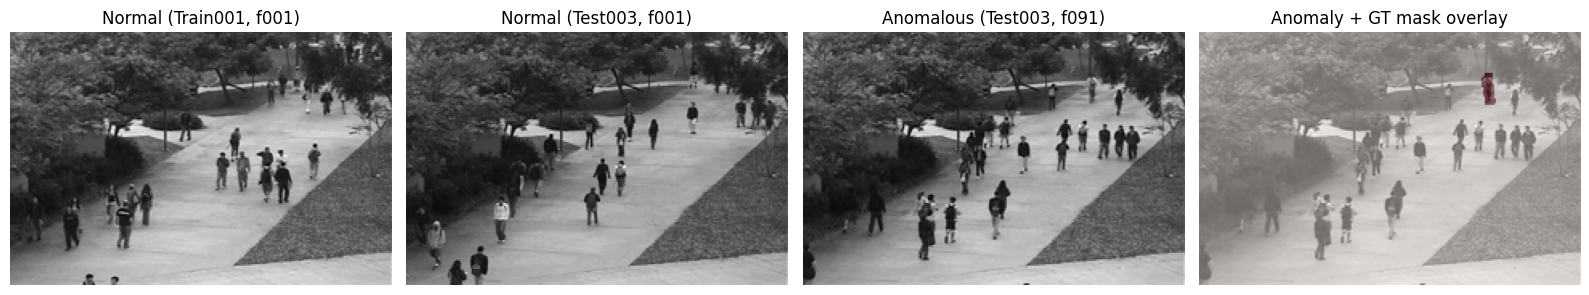

In [12]:
def load_gray(path: Path) -> np.ndarray:
  return np.array(Image.open(path).convert("L"))

normal_train = load_gray(PED1_PATH / "Train" / "Train001" / "001.tif")
normal_test = load_gray(PED1_PATH / "Test" / "Test003" / "001.tif")
anomaly_frame = load_gray(PED1_PATH / "Test" / "Test003" / "091.tif")
anomaly_mask = load_gray(PED1_PATH / "Test" / "Test003_gt" / "091.bmp")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(normal_train, cmap="gray"); axes[0].set_title("Normal (Train001, f001)")
axes[1].imshow(normal_test, cmap="gray"); axes[1].set_title("Normal (Test003, f001)")
axes[2].imshow(anomaly_frame, cmap="gray"); axes[2].set_title("Anomalous (Test003, f091)")
axes[3].imshow(anomaly_frame, cmap="gray")
axes[3].imshow(anomaly_mask, cmap="Reds", alpha=0.4)
axes[3].set_title("Anomaly + GT mask overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Anomaly Frame Ration and Mask Area Statistics
Calculating and displays a brief statistics on anomalous frames, including the percentage of frames with anomalies and the average anomaly area as a percentage of frame size for both the datsets.

In [16]:
def sequence_anomaly_stats(gt_dir: Path) -> dict:
  #Return fraction of frames with any anomaly and mean anomaly area as a percentage(%) of the frame.
  gt_files = sorted(p for p in gt_dir.iterdir() if p.is_file() and p.suffix.lower() == ".bmp")
  frame_flags, area_fracs = [], []
  for f in gt_files:
    arr = np.array(Image.open(f))
    is_anomalous = (arr>0).any()
    frame_flags.append(is_anomalous)
    if is_anomalous:
      area_fracs.append((arr>0).mean())
  return {
      "num_frames": len(gt_files),
      "num_anomalous_frames": sum(frame_flags),
      "mean_anomaly_area_pct": np.mean(area_fracs) * 100 if area_fracs else 0.0,
  }

anomaly_rows = []
for ped_path, ped_name in [(PED1_PATH, "Ped1"), (PED2_PATH, "Ped2")]:
    test_path = ped_path / "Test"
    for seq_dir in sorted(test_path.iterdir()):
        if seq_dir.is_dir() and seq_dir.name.endswith("_gt"):
            stats = sequence_anomaly_stats(seq_dir)
            anomaly_rows.append({"dataset": ped_name, "sequence": seq_dir.name.replace("_gt", ""), **stats})

anomaly_df = pd.DataFrame(anomaly_rows)
anomaly_df["anomalous_frame_pct"] = (anomaly_df["num_anomalous_frames"] / anomaly_df["num_frames"] * 100).round(1)
print(anomaly_df.groupby("dataset")[["anomalous_frame_pct", "mean_anomaly_area_pct"]].mean().round(1))
anomaly_df

         anomalous_frame_pct  mean_anomaly_area_pct
dataset                                            
Ped1                    61.8                    0.9
Ped2                    83.0                    1.3


,dataset,sequence,num_frames,num_anomalous_frames,mean_anomaly_area_pct,anomalous_frame_pct
0,Ped1,Test003,200,110,0.414995,55.0
1,Ped1,Test004,200,138,0.310964,69.0
2,Ped1,Test014,200,200,2.117355,100.0
3,Ped1,Test018,200,67,0.415445,33.5
4,Ped1,Test019,200,75,1.394532,37.5
5,Ped1,Test021,200,170,0.648054,85.0
6,Ped1,Test022,200,92,0.444044,46.0
7,Ped1,Test023,200,158,0.517569,79.0
8,Ped1,Test024,200,122,1.553833,61.0
9,Ped1,Test032,200,103,0.822470,51.5


## 11. Vidualization: PED2 Sample
Visual demonstration of an anomalous frame from the Ped2 dataset, showing the original image and an overlay of its corresponding ground truth mask.

## 12. Canonical Ground Truth Metadata Generation

### Developer & Debugging Notes:
- **The Missing Test Data Bug:** When initially building metadata, we checked for `{seq}_gt` pixel mask folders. We realized that in UCSD Ped1, the dataset authors only made pixel masks for 10 out of the 36 test sequences!
- **Canonical MATLAB Ground Truth:** The other 26 sequences only have frame range intervals specified in `UCSDped1.m`. Checking only for folders silently dropped 72% of the test set.
- **Fix:** Here we parse `UCSDped1.m` and `UCSDped2.m` directly with regex so all 36 Ped1 test sequences (7,200 frames) and all 12 Ped2 test sequences get canonical ground truth in `metadata.csv`.


In [18]:
%%writefile "{REPO_DIR}/src/data/generate_metadata.py"
"""
Generate metadata.csv from the local UCSD dataset.

Parses the canonical MATLAB ground-truth files (UCSDped1.m and UCSDped2.m)
to extract frame-level ground-truth annotations for all 36 test sequences in
Ped1 and 12 in Ped2. Also tracks pixel-level mask folder existence.

Usage:
    python -m src.data.generate_metadata
"""

import re
from pathlib import Path
import pandas as pd

FRAME_SUFFIXES = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}
GT_SUFFIXES = {".bmp"}
IGNORE_NAMES = {".DS_Store", "._.DS_Store", "._README.txt"}


def count_files(dir_path: Path, suffixes: set) -> int:
    """Count files in dir_path matching given suffixes, ignoring OS files."""
    if not dir_path.exists():
        return 0
    return sum(
        1 for p in dir_path.iterdir()
        if p.is_file() and p.suffix.lower() in suffixes and p.name not in IGNORE_NAMES
    )


def parse_matlab_gt(m_path: Path) -> dict[str, list[int]]:
    """
    Parse canonical UCSD .m ground-truth annotation files.
    
    Lines typically look like:
        TestVideoFile{end+1}.gt_frame = [60:152];
        TestVideoFile{end+1}.gt_frame = [5:90, 140:200];
    
    Returns:
        dict mapping 'Test001', 'Test002', etc. to list of 1-indexed anomalous frame numbers.
    """
    if not m_path.exists():
        return {}

    gt_map = {}
    content = m_path.read_text(encoding="utf-8", errors="ignore")
    lines = [line.strip() for line in content.splitlines() if "gt_frame" in line]

    for idx, line in enumerate(lines, start=1):
        seq_name = f"Test{idx:03d}"
        m = re.search(r"\[(.*?)\]", line)
        frames = set()
        if m and m.group(1).strip():
            raw_ranges = m.group(1).split(",")
            for part in raw_ranges:
                part = part.strip()
                if not part:
                    continue
                if ":" in part:
                    s, e = map(int, part.split(":"))
                    frames.update(range(s, e + 1))
                else:
                    frames.add(int(part))
        gt_map[seq_name] = sorted(frames)

    return gt_map


def build_inventory(ped_path: Path, ped_name: str) -> list[dict]:
    """Walk Train/Test folders of one Ped dataset and attach canonical ground truth."""
    rows = []
    m_filename = f"UCSD{ped_name.lower()}.m"
    # Canonical GT is inside Test/ directory
    matlab_gt = parse_matlab_gt(ped_path / "Test" / m_filename)
    if not matlab_gt:
        # Fallback to ped_path root
        matlab_gt = parse_matlab_gt(ped_path / m_filename)

    for split in ("Train", "Test"):
        split_path = ped_path / split
        if not split_path.exists():
            continue

        for seq_dir in sorted(split_path.iterdir()):
            if not seq_dir.is_dir() or seq_dir.name in IGNORE_NAMES:
                continue
            if seq_dir.name.endswith("_gt"):
                continue

            num_frames = count_files(seq_dir, FRAME_SUFFIXES)
            gt_dir = split_path / f"{seq_dir.name}_gt"
            has_pixel_mask = gt_dir.exists()

            if split == "Test":
                anom_frames = matlab_gt.get(seq_dir.name, [])
                has_gt = len(anom_frames) > 0 or (seq_dir.name in matlab_gt)
                num_gt_frames = len(anom_frames)
            else:
                anom_frames = []
                has_gt = False
                num_gt_frames = 0

            rows.append({
                "dataset": ped_name,
                "split": split,
                "sequence": seq_dir.name,
                "num_frames": num_frames,
                "has_gt": has_gt,
                "num_anom_frames": num_gt_frames,
                "has_pixel_mask": has_pixel_mask,
                "num_pixel_masks": count_files(gt_dir, GT_SUFFIXES) if has_pixel_mask else 0,
            })

    return rows


def generate_metadata(
    data_root: Path | str | None = None,
    output_path: Path | str | None = None,
) -> pd.DataFrame:
    """
    Scan the UCSD dataset and produce a metadata CSV with canonical ground-truth info.
    """
    project_root = Path(__file__).resolve().parent.parent.parent

    if data_root is None:
        data_root = project_root / "data" / "raw" / "UCSD_Anomaly_Dataset"
    data_root = Path(data_root)

    if output_path is None:
        output_path = project_root / "data" / "metadata.csv"
    output_path = Path(output_path)

    ped1_path = data_root / "UCSDped1"
    ped2_path = data_root / "UCSDped2"

    if not ped1_path.exists() and not ped2_path.exists():
        raise FileNotFoundError(
            f"Neither UCSDped1 nor UCSDped2 found in {data_root}.\n"
            f"Please extract UCSD_Anomaly_Dataset.zip into data/raw/"
        )

    inventory = []
    if ped1_path.exists():
        inventory.extend(build_inventory(ped1_path, "Ped1"))
    if ped2_path.exists():
        inventory.extend(build_inventory(ped2_path, "Ped2"))

    df = pd.DataFrame(inventory)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"Metadata saved to: {output_path}")
    print(f"  Total sequences: {len(df)}")
    ped1_test = df[(df["dataset"] == "Ped1") & (df["split"] == "Test")]
    ped2_test = df[(df["dataset"] == "Ped2") & (df["split"] == "Test")]
    print(f"  Ped1 Test sequences with GT: {ped1_test['has_gt'].sum()} / {len(ped1_test)}")
    print(f"  Ped2 Test sequences with GT: {ped2_test['has_gt'].sum()} / {len(ped2_test)}")

    return df


if __name__ == "__main__":
    generate_metadata()


Saved: /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/data/metadata.csv


In [19]:
# %cd "{REPO_DIR}"
# !git add notebooks/02_ucsd_dataset_exploration.ipynb
# !git commit -m "Comprehensive exploration and validation of the UCSD Anomaly Dataset"
# !git push

/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
[main 101eed7] Comprehensive exploration and validation of the UCSD Anomaly Dataset
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite notebooks/02_ucsd_dataset_exploration.ipynb (88%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 581.65 KiB | 7.09 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Rishabh-G-Shetye/SurveillanceAnomalyDetection.git
   e347de2..101eed7  main -> main
